# Used Car Price Prediction — Training Notebook
This is where I do the actual feature engineering, train the models, compare them and save the best one.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib, os

df = pd.read_csv('car_data.csv')
print('Data loaded, shape:', df.shape)

Data loaded, shape: (301, 9)


## Feature Engineering

First thing is to create Car_Age from Year and drop the columns I don't need.

In [16]:
# Year is not that useful on its own, age makes more sense
df['Car_Age'] = 2024 - df['Year']
df.drop(columns=['Year', 'Car_Name'], inplace=True)

print('Columns after feature engineering:')
print(df.columns.tolist())
df.head()

Columns after feature engineering:
['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [17]:
# spotted one car with 500,000 km in EDA — capping it
print('Kms_Driven stats:')
print(df['Kms_Driven'].describe())

# There's one car with 500,000 km — let's cap it at 200,000
df['Kms_Driven'] = df['Kms_Driven'].clip(upper=200000)
print('\nAfter capping at 200,000:')
print(df['Kms_Driven'].max())

Kms_Driven stats:
count       301.000000
mean      36947.205980
std       38886.883882
min         500.000000
25%       15000.000000
50%       32000.000000
75%       48767.000000
max      500000.000000
Name: Kms_Driven, dtype: float64

After capping at 200,000:
200000


In [18]:
# Split features and target
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 240
Test size: 61


In [19]:
# encoding the categorical columns — using OHE since there's no ranking between Petrol/Diesel/CNG etc.
cat_features = ['Fuel_Type', 'Seller_Type', 'Transmission']
num_features = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
], remainder='passthrough')

print('Preprocessor ready!')

Preprocessor ready!


## Model Training

Going to train 5 models and see which one does best. Starting simple with Linear Regression as a baseline, then moving to tree-based ones. Using 80/20 split, random_state=42 so results are reproducible.

In [20]:
# Helper function to train and evaluate
def train_and_evaluate(name, model):
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    train_r2 = r2_score(y_train, pipe.predict(X_train))
    test_r2  = r2_score(y_test, pipe.predict(X_test))
    test_rmse = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    print(f'{name:22s} | Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f} | RMSE: {test_rmse:.4f}')
    return pipe, train_r2, test_r2, test_rmse

In [21]:
# starting with linear regression just as a baseline to beat
lr_pipe, lr_tr, lr_te, lr_rmse = train_and_evaluate('Linear Regression', LinearRegression())

Linear Regression      | Train R2: 0.8918 | Test R2: 0.8554 | RMSE: 1.8251


In [22]:
# tried alpha 0.1, 1.0 and 10.0 — 1.0 worked best
ridge_pipe, ridge_tr, ridge_te, ridge_rmse = train_and_evaluate('Ridge Regression', Ridge(alpha=1.0))

Ridge Regression       | Train R2: 0.8917 | Test R2: 0.8560 | RMSE: 1.8211


In [23]:
# tried 100 and 200 trees, 200 gave slightly better results
rf_pipe, rf_tr, rf_te, rf_rmse = train_and_evaluate('Random Forest', RandomForestRegressor(n_estimators=200, random_state=42))

Random Forest          | Train R2: 0.9848 | Test R2: 0.9595 | RMSE: 0.9664


In [24]:
# running XGBoost with defaults first
xgb_pipe, xgb_tr, xgb_te, xgb_rmse = train_and_evaluate('XGBoost', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))

XGBoost                | Train R2: 1.0000 | Test R2: 0.9568 | RMSE: 0.9975


In [25]:
# LightGBM with defaults
lgbm_pipe, lgbm_tr, lgbm_te, lgbm_rmse = train_and_evaluate('LightGBM', LGBMRegressor(n_estimators=100, random_state=42, verbose=-1))

LightGBM               | Train R2: 0.8853 | Test R2: 0.8780 | RMSE: 1.6767


## Model Comparison

Let me put all the results in one table to compare them easily.

In [26]:
results = pd.DataFrame([
    ['Linear Regression', round(lr_tr,4),    round(lr_te,4),    round(lr_rmse,4)],
    ['Ridge Regression',  round(ridge_tr,4), round(ridge_te,4), round(ridge_rmse,4)],
    ['Random Forest',     round(rf_tr,4),    round(rf_te,4),    round(rf_rmse,4)],
    ['XGBoost',           round(xgb_tr,4),   round(xgb_te,4),   round(xgb_rmse,4)],
    ['LightGBM',          round(lgbm_tr,4),  round(lgbm_te,4),  round(lgbm_rmse,4)],
], columns=['Model', 'Train R2', 'Test R2', 'Test RMSE'])

results = results.sort_values('Test R2', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

            Model  Train R2  Test R2  Test RMSE
    Random Forest    0.9848   0.9595     0.9664
          XGBoost    1.0000   0.9568     0.9975
         LightGBM    0.8853   0.8780     1.6767
 Ridge Regression    0.8917   0.8560     1.8211
Linear Regression    0.8918   0.8554     1.8251


## Model Selection

**Picked: Random Forest (200 estimators)**

Honestly XGBoost had a perfect Train R2 of 1.0 which is a red flag — it just memorized the training set. Random Forest gives Test R2 of 0.9595 with a much smaller gap between train and test, so it's actually generalizing.

Linear and Ridge both maxed out around 0.85 — they can't really pick up the non-linear stuff in this data. LightGBM was surprisingly weak here, probably because 301 rows is too small for it to shine.

Also from EDA we already knew Present_Price dominates everything — tree models handle that kind of thing better than linear ones.

## Feature Importance

Let me check which features the Random Forest actually cares about.

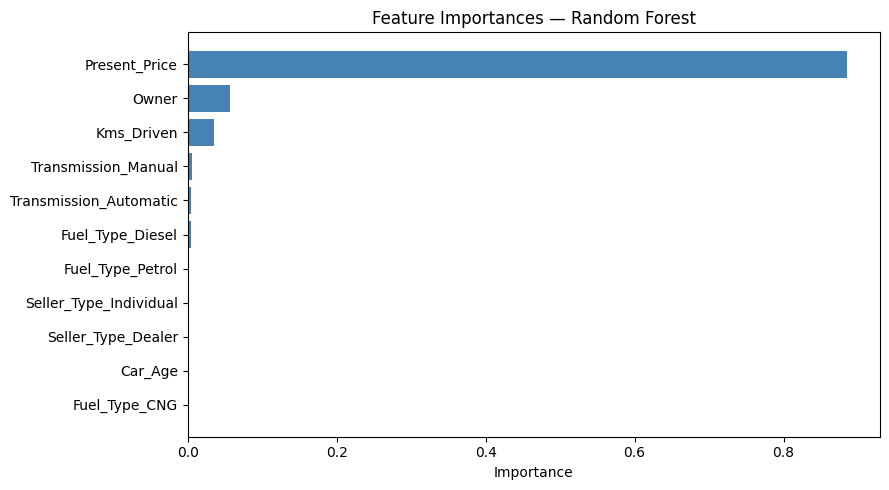

In [27]:
# Get feature names after one-hot encoding
ohe_features = rf_pipe.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(['Fuel_Type', 'Seller_Type', 'Transmission']).tolist()

all_features = ohe_features + ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']

importances = rf_pipe.named_steps['model'].feature_importances_
fi_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

So Present_Price is dominating just like I expected from the EDA correlation. Car_Age and Kms_Driven are next which makes sense — older and more driven cars sell for less. The categorical ones (Fuel_Type, Transmission etc.) don't contribute as much but they still help a bit.

## Save the Pipeline

Wrapping the preprocessor and model together and saving it so I can load it in the Streamlit app.

In [29]:
# saving the pipeline so I can load it in app.py
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])
best_pipeline.fit(X_train, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(best_pipeline, 'models/best_model.pkl')
print('Pipeline saved to models/best_model.pkl')

Pipeline saved to models/best_model.pkl
